In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

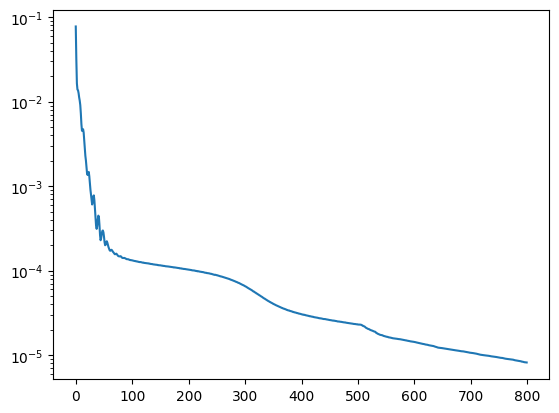

In [9]:
t = np.genfromtxt('checkpoints/losses.txt')
# t2 = np.genfromtxt('checkpoints_withlbfgs/losses.txt')
# t3 = np.genfromtxt('checkpoints_laml25_01/losses.txt')

plt.plot(t)

# n = np.arange(len(t), len(t)+len(t2))
# plt.plot(n, t2)
# plt.plot(n, t3)
plt.yscale('log')
# plt.axhline(8.9e-3)
# plt.xlim(22000, 22000+len(t2)+1000)
# plt.xlim(1000, 2000)
# plt.ylim(1e3, 5e3)

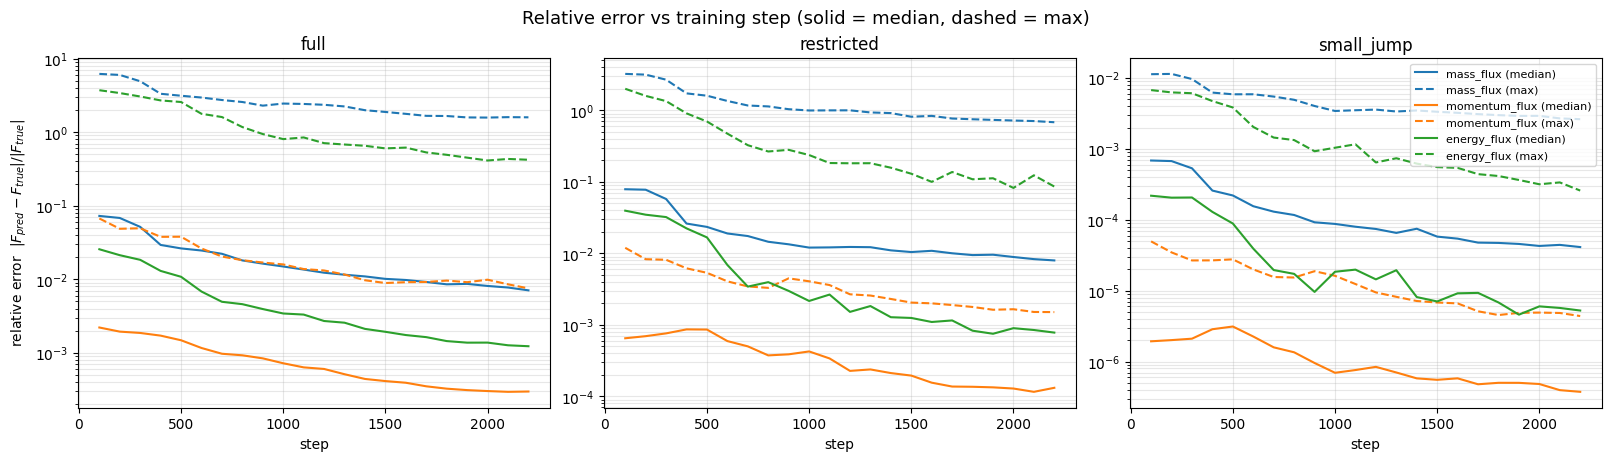

In [13]:
# Add metrics plot here
import csv
from pathlib import Path

import matplotlib.pyplot as plt

metrics_path = Path("checkpoints/metrics.csv")
with metrics_path.open() as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]

domains = ("full", "restricted", "small_jump")
channels = ("mass_flux", "momentum_flux", "energy_flux")
colors = {ch: c for ch, c in zip(channels, ("C0", "C1", "C2"))}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, constrained_layout=True)

for ax, domain in zip(axes, domains):
    for ch in channels:
        median = [float(r[f"median_rel_{domain}_{ch}"]) for r in rows]
        mx = [float(r[f"max_rel_{domain}_{ch}"]) for r in rows]
        ax.plot(steps, median, "-", color=colors[ch], label=f"{ch} (median)")
        ax.plot(steps, mx, "--", color=colors[ch], label=f"{ch} (max)")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(domain)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel(r"relative error  $|F_{pred} - F_{true}| / |F_{true}|$")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Relative error vs training step (solid = median, dashed = max)", fontsize=13)
plt.show()

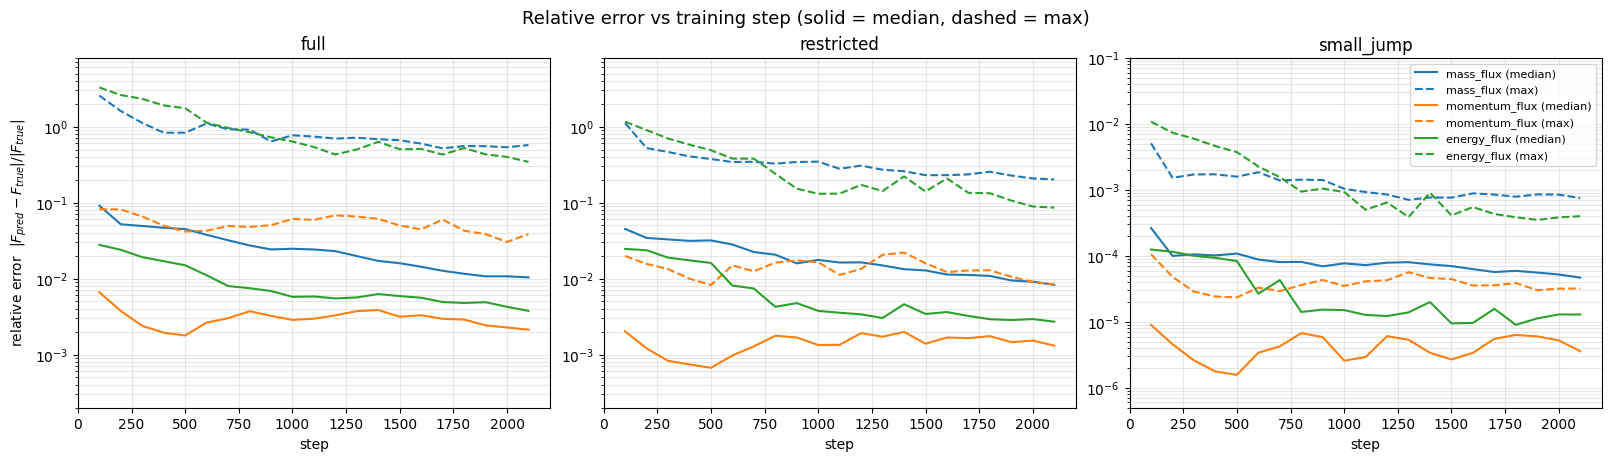

In [17]:
# Add metrics plot here
import csv
from pathlib import Path

import matplotlib.pyplot as plt

metrics_path = Path("checkpoints_rel/metrics.csv")
with metrics_path.open() as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]

domains = ("full", "restricted", "small_jump")
channels = ("mass_flux", "momentum_flux", "energy_flux")
colors = {ch: c for ch, c in zip(channels, ("C0", "C1", "C2"))}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, constrained_layout=True)

for ax, domain in zip(axes, domains):
    for ch in channels:
        median = [float(r[f"median_rel_{domain}_{ch}"]) for r in rows]
        mx = [float(r[f"max_rel_{domain}_{ch}"]) for r in rows]
        ax.plot(steps, median, "-", color=colors[ch], label=f"{ch} (median)")
        ax.plot(steps, mx, "--", color=colors[ch], label=f"{ch} (max)")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(domain)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylim(2e-4, 8e0)
axes[1].set_ylim(2e-4, 8e0)
axes[2].set_ylim(5e-7, 1e-1)

axes[0].set_ylabel(r"relative error  $|F_{pred} - F_{true}| / |F_{true}|$")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Relative error vs training step (solid = median, dashed = max)", fontsize=13)
plt.show()

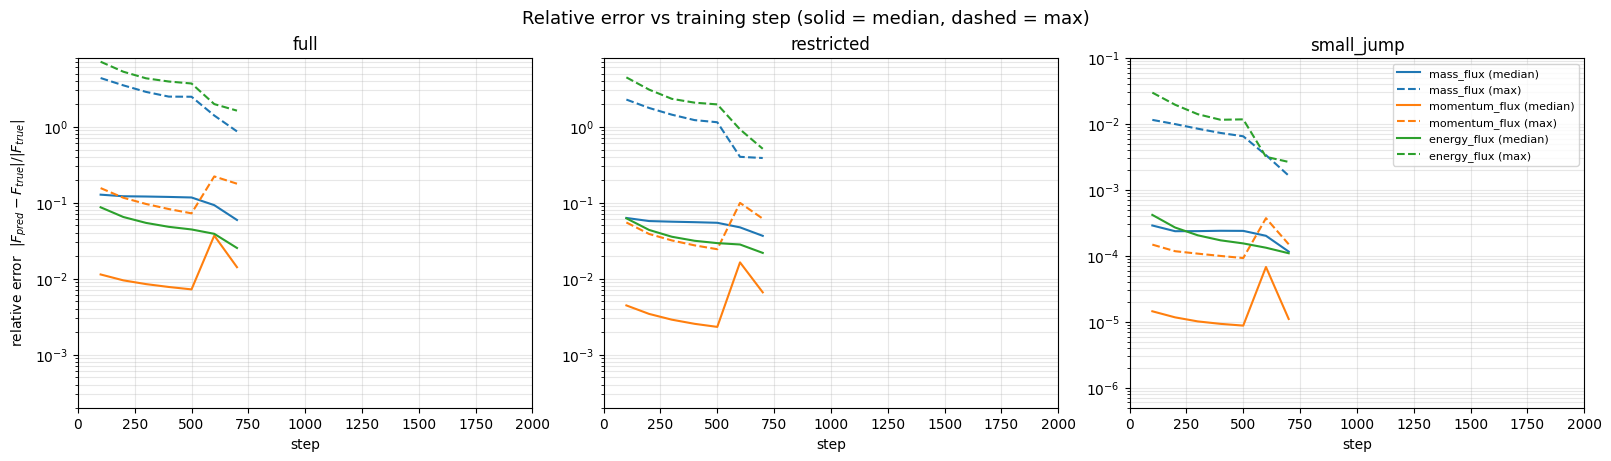

In [19]:
# Add metrics plot here
import csv
from pathlib import Path

import matplotlib.pyplot as plt

metrics_path = Path("checkpoints_rel_l4/metrics.csv")
with metrics_path.open() as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]

domains = ("full", "restricted", "small_jump")
channels = ("mass_flux", "momentum_flux", "energy_flux")
colors = {ch: c for ch, c in zip(channels, ("C0", "C1", "C2"))}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, constrained_layout=True)

for ax, domain in zip(axes, domains):
    for ch in channels:
        median = [float(r[f"median_rel_{domain}_{ch}"]) for r in rows]
        mx = [float(r[f"max_rel_{domain}_{ch}"]) for r in rows]
        ax.plot(steps, median, "-", color=colors[ch], label=f"{ch} (median)")
        ax.plot(steps, mx, "--", color=colors[ch], label=f"{ch} (max)")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(domain)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlim(0, 2000)

axes[0].set_ylim(2e-4, 8e0)
axes[1].set_ylim(2e-4, 8e0)
axes[2].set_ylim(5e-7, 1e-1)

axes[0].set_ylabel(r"relative error  $|F_{pred} - F_{true}| / |F_{true}|$")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Relative error vs training step (solid = median, dashed = max)", fontsize=13)
plt.show()

In [ ]:
from train import TRAIN_BOUNDS, F_true
from physics import GasState, flux_from_primitive_state
import jax.numpy as jnp
import jax
names = ["t", "log10_rhoL", "log10_pL", "log10_rhoR", "log10_pR", "uRL"]

from checkpoint import load_latest
from train import F_pred, _build_model

ckpt_dir = Path.cwd() / "checkpoints"
F_net, _ = load_latest(ckpt_dir, _build_model)

ckpt_dir = Path.cwd() / "checkpoints_lamrel_01"
F_net_rel, _ = load_latest(ckpt_dir, _build_model)


gas_states = []
bound_pairs = []
name_pairs = []
fluxes = []
fluxes_div = []
fluxes_pred = []
fluxes_rel_pred = []

fluxes_L = []
fluxes_R = []
fluxes_LR = []

N_grid = 512

# defaults
t_grid = jnp.full((N_grid**2,), 0.5)
log10_rhoL_grid = jnp.zeros((N_grid**2,))
log10_pL_grid = jnp.zeros((N_grid**2,))
log10_rhoR_grid = jnp.zeros((N_grid**2,))
log10_pR_grid = jnp.zeros((N_grid**2,))
uRL_grid = jnp.full((N_grid**2,), 0.0)
default_grids = [t_grid, log10_rhoL_grid, log10_pL_grid, log10_rhoR_grid, log10_pR_grid, uRL_grid]

for i in range(len(TRAIN_BOUNDS)):
    for j in range(len(TRAIN_BOUNDS)):
        if i==0 or j==0 or i==j or i>j:
            continue

        bound_pairs.append((TRAIN_BOUNDS[i], TRAIN_BOUNDS[j]))
        
        lin_i = jnp.linspace(TRAIN_BOUNDS[i][0], TRAIN_BOUNDS[i][1], N_grid)
        lin_j = jnp.linspace(TRAIN_BOUNDS[j][0], TRAIN_BOUNDS[j][1], N_grid)
        X, Y = jnp.meshgrid(lin_i, lin_j, indexing="ij")

        grid_array = []
        for k in range(len(TRAIN_BOUNDS)):
            if k==i:
                grid_array.append(X.flatten())
            elif k==j:
                grid_array.append(Y.flatten())
            else:
                grid_array.append(default_grids[k])

        grid = jnp.stack(grid_array, axis=-1)
        gas_states.append(GasState.from_array(grid))

        name_pairs.append((names[i], names[j]))
        # print(name_pairs[-1])

        flux_ = jax.vmap(F_true)(grid)
        fluxes.append(jnp.reshape(flux_, (N_grid, N_grid, 3)))

        # pL - pR
        pRpL = 10.**(grid_array[4]) - 10.**(grid_array[2])
        # uRL
        uRL = grid_array[5]
        # rhoR - rhoL
        rhoRrhoL = 10.**(grid_array[3]) - 10.**(grid_array[1])
        denom = (pRpL * uRL * rhoRrhoL)[..., None]

        fluxes_div.append(jnp.reshape(flux_ / denom, (N_grid, N_grid, 3)))

        flux_pred_ = jax.vmap(lambda r: F_pred(F_net, r))(grid)
        fluxes_pred.append(jnp.reshape(flux_pred_, (N_grid, N_grid, 3)))

        flux_pred_rel_ = jax.vmap(lambda r: F_pred(F_net_rel, r))(grid)
        fluxes_rel_pred.append(jnp.reshape(flux_pred_rel_, (N_grid, N_grid, 3)))


        # left and right fluxes
        rhoL = 10.**(grid_array[1])
        rhoR = 10.**(grid_array[3])
        uR = grid_array[5]
        uL = jnp.zeros_like(uR)
        pL = 10.**(grid_array[2])
        pR = 10.**(grid_array[4])

        flux_L_ = jax.vmap(flux_from_primitive_state)(rhoL, uL, pL)
        flux_R_ = jax.vmap(flux_from_primitive_state)(rhoR, uR, pR)
        fluxes_L.append(jnp.reshape(flux_L_, (N_grid, N_grid, 3)))
        fluxes_R.append(jnp.reshape(flux_R_, (N_grid, N_grid, 3)))
        fluxes_LR.append(jnp.reshape(0.5 * (flux_L_ + flux_R_), (N_grid, N_grid, 3)))


loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints/F_net_022000.msgpack
loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints_lamrel_01/F_net_024000.msgpack


In [22]:
print(grid_array[4])

[-2. -2. -2. ...  2.  2.  2.]


min flux [-1.00000000e+02  1.00000000e-02 -1.82670119e+03]
max flux [  40.84787123  101.         1826.70118567]


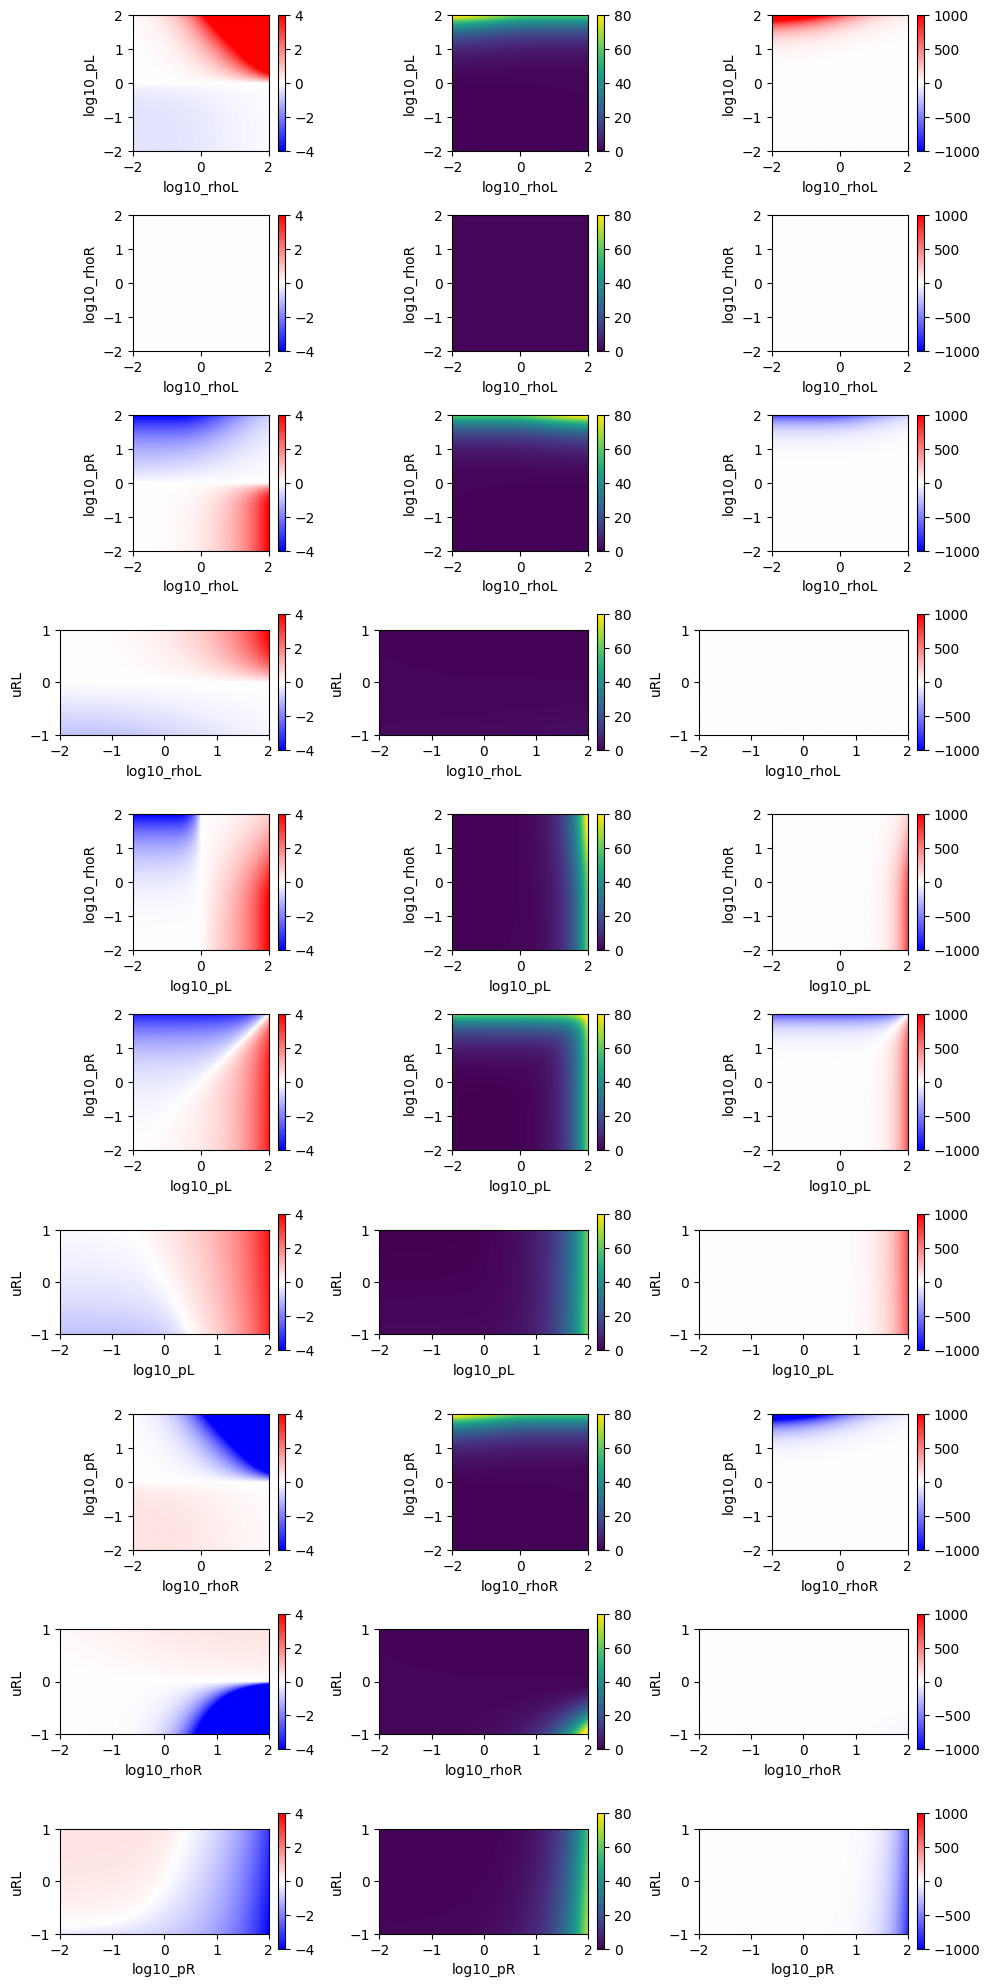

In [7]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):
    min_flux = jnp.minimum(min_flux, fluxes[i].min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, fluxes[i].max(axis=(0,1)))
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]

        if j==0:
            cmap = 'bwr'
            vmax = 4
            vmin = -vmax
        if j==1:
            cmap = 'viridis'
            vmax = 80
            vmin = 0
        if j==2:
            cmap = 'bwr'
            vmax = 1000
            vmin = -vmax

        im = ax.imshow(fluxes[i][...,j].T, origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


0 [0.    0.505 0.   ] [ 0.  50.5  0. ]
1 [0.    0.505 0.   ] [ 0.  50.5  0. ]
2 [0.    0.505 0.   ] [ 0.  50.5  0. ]
3 [-0.5    0.505 -1.5  ] [ 0.5 50.5  1.5]
4 [-0.5    0.505 -1.5  ] [ 0.5 50.5  1.5]
5 [-0.5   0.01 -1.5 ] [  0.5 100.    1.5]
6 [-0.5   0.01 -1.5 ] [  0.5 100.    1.5]
7 [-0.5   0.01 -1.5 ] [  0.5 100.    1.5]
8 [-5.000e+01  1.000e-02 -2.625e+01] [ 50.   100.    26.25]
9 [-5.0000e+01  1.0000e-02 -1.2525e+02] [ 50.   100.   125.25]
min flux [-5.0000e+01  1.0000e-02 -1.2525e+02]
max flux [ 50.   100.   125.25]


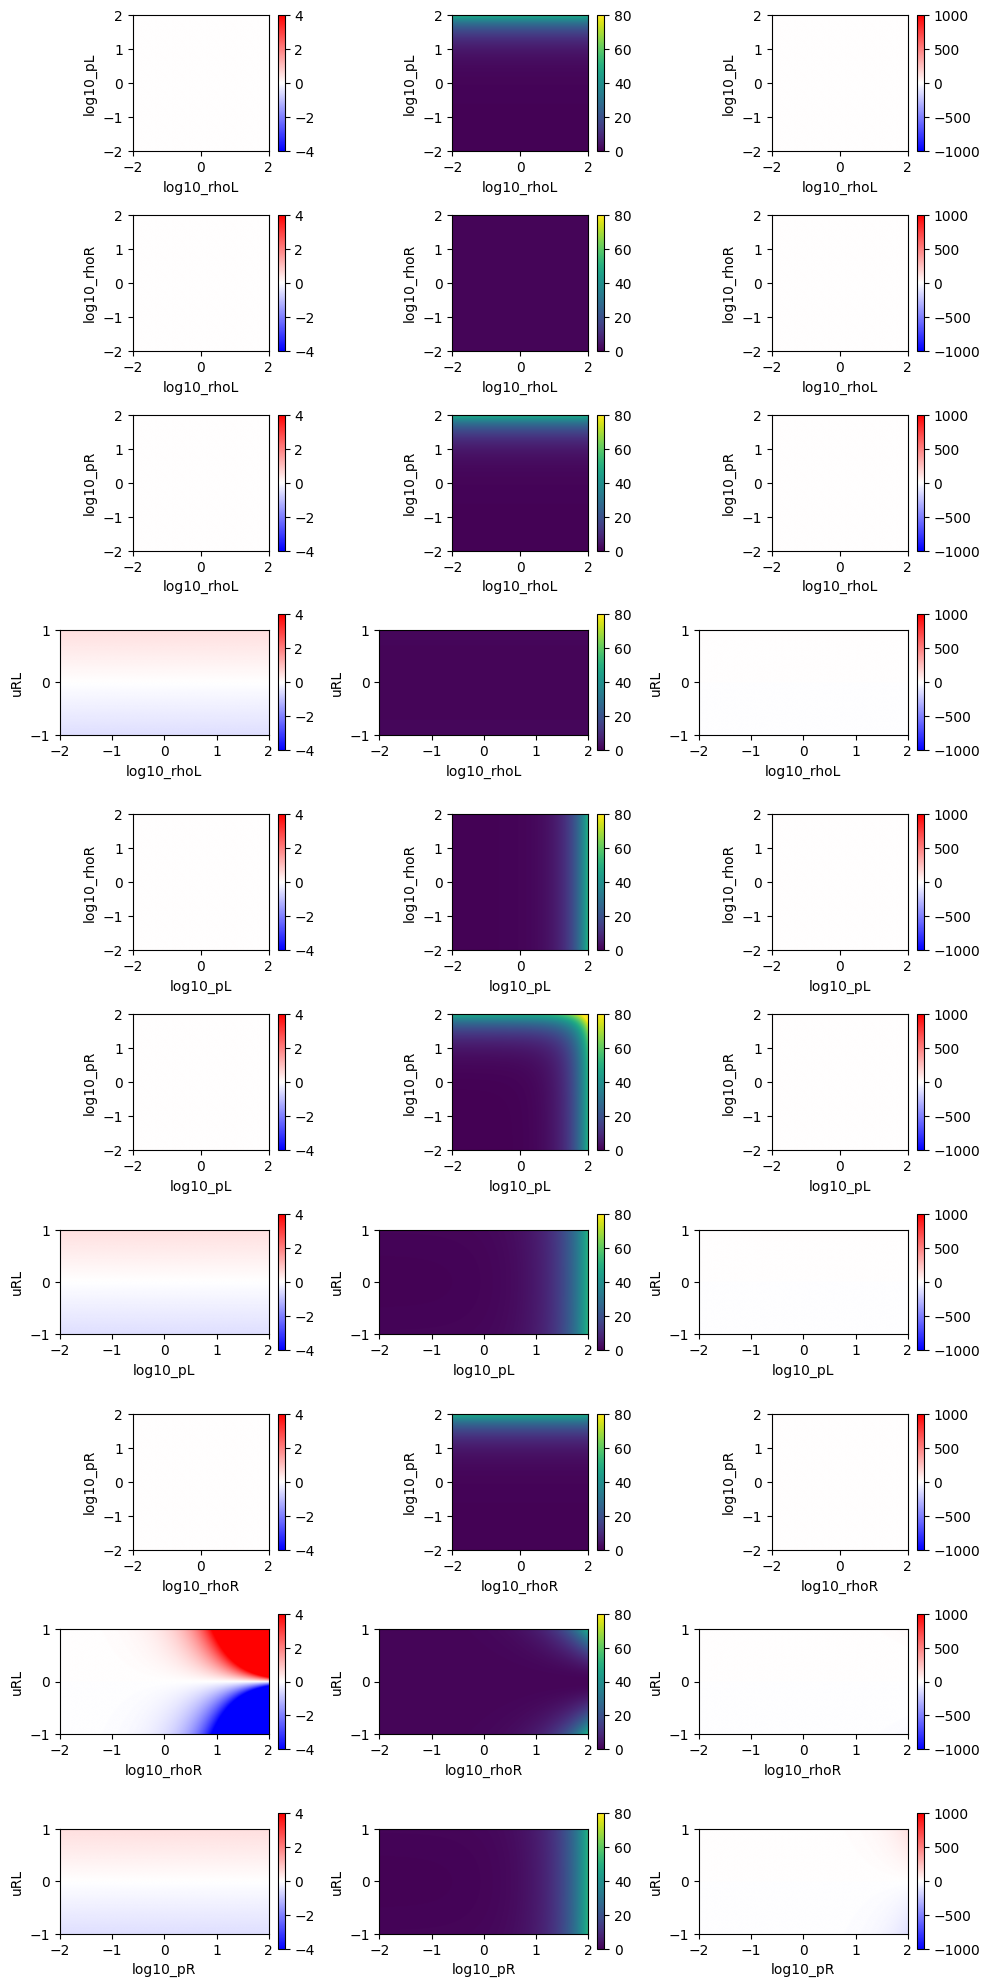

In [23]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):
    
    min_flux = jnp.minimum(min_flux, fluxes_LR[i].min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, fluxes_LR[i].max(axis=(0,1)))

    print(i, min_flux, max_flux)
    
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]

        if j==0:
            cmap = 'bwr'
            vmax = 4
            vmin = -vmax
        if j==1:
            cmap = 'viridis'
            vmax = 80
            vmin = 0
        if j==2:
            cmap = 'bwr'
            vmax = 1000
            vmin = -vmax

        im = ax.imshow(fluxes_LR[i][...,j].T, origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


0 [-0.40847871 -0.13997494 -0.76589759] [  40.84787123   40.07529778 1826.70118567]
1 [-0.40847871 -0.13997494 -0.76589759] [  40.84787123   40.07529778 1826.70118567]
2 [-4.08478712e+00 -1.39974939e-01 -7.65897586e+02] [  40.84787123   40.07529778 1826.70118567]
3 [  -4.08478712   -0.86713241 -765.89758555] [  40.84787123   40.07529778 1826.70118567]
4 [  -4.08478712   -0.86713241 -765.89758555] [  40.84787123   40.07529778 1826.70118567]
5 [  -4.08478712   -0.86713241 -765.89758555] [  40.84787123   40.07529778 1826.70118567]
6 [  -4.08478712   -0.89223782 -765.89758555] [  40.84787123   40.07529778 1826.70118567]
7 [-4.08478712e+01 -8.92237815e-01 -1.82670119e+03] [  40.84787123   40.07529778 1826.70118567]
8 [  -50.           -50.36713241 -1826.70118567] [  40.84787123   50.         1826.70118567]
9 [  -50.           -50.36713241 -1826.70118567] [  40.84787123   50.         1826.70118567]
min flux [  -50.           -50.36713241 -1826.70118567]
max flux [  40.84787123   50.         

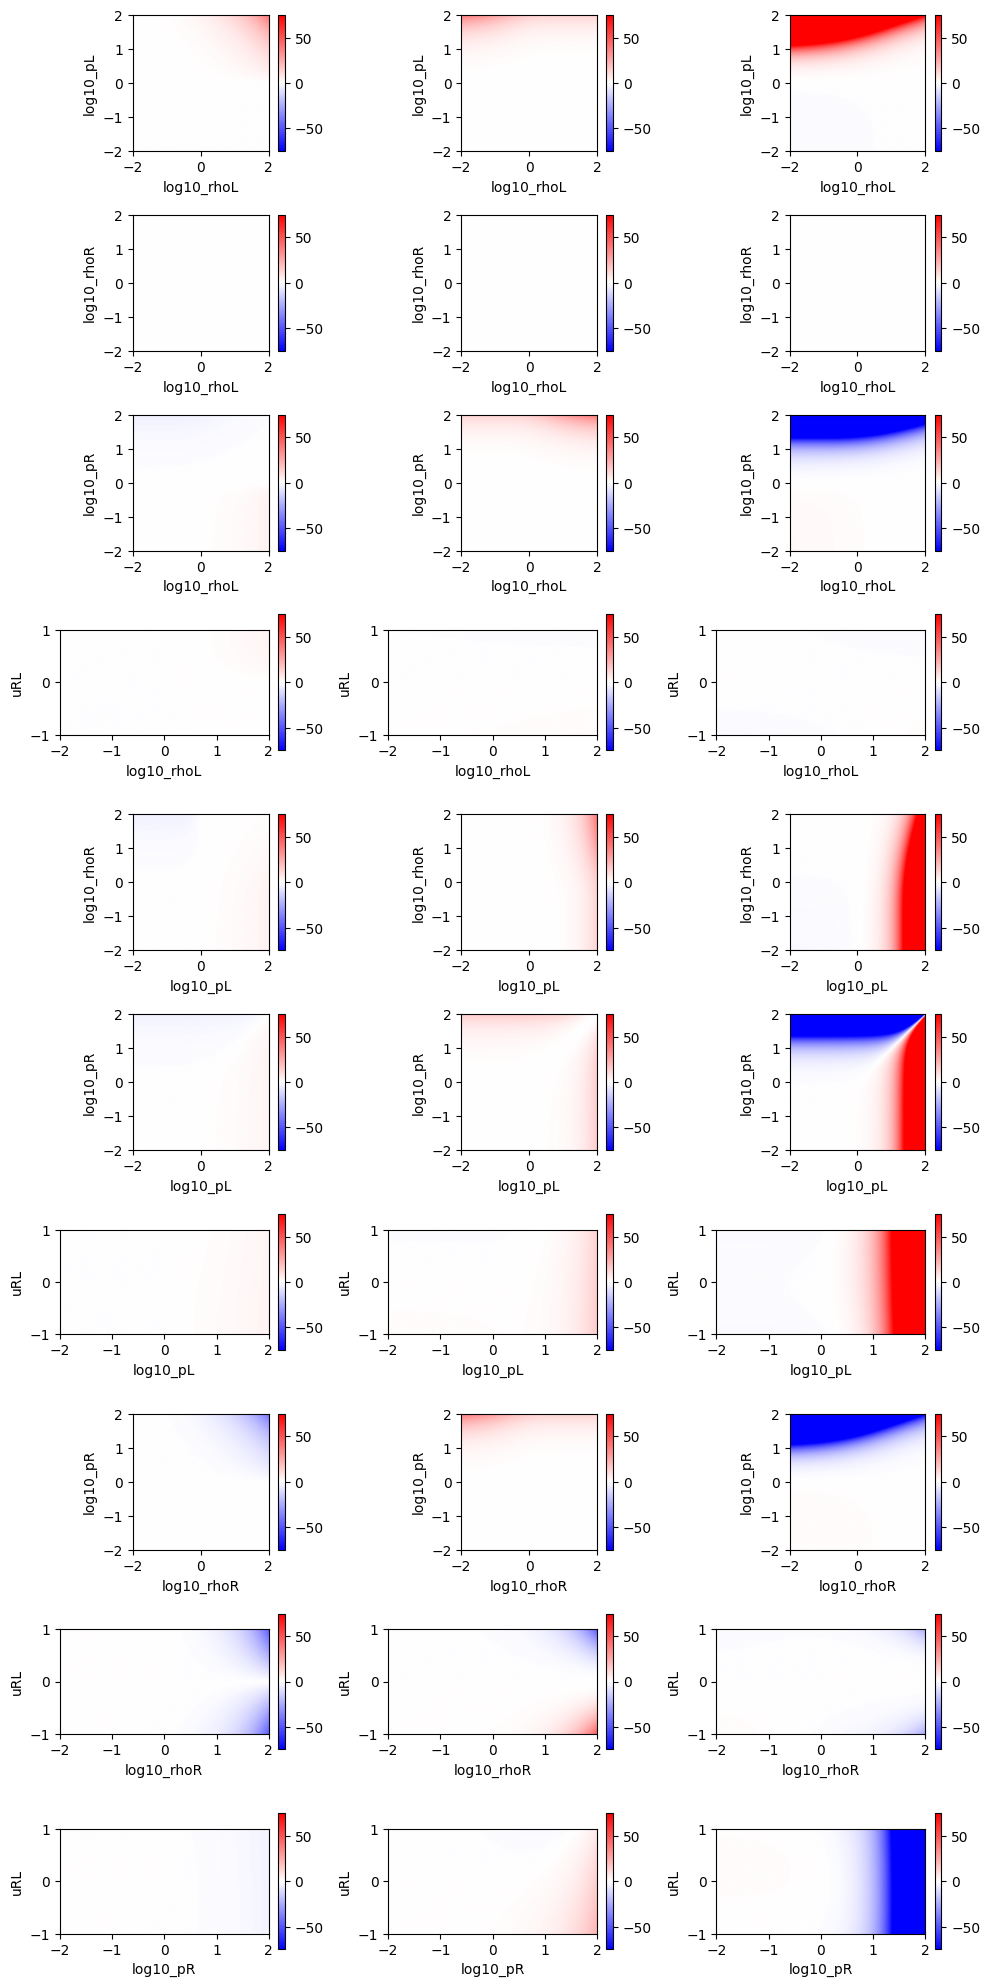

In [18]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):

    flux_diff = fluxes[i] - fluxes_LR[i]
    
    min_flux = jnp.minimum(min_flux, flux_diff.min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, flux_diff.max(axis=(0,1)))

    print(i, min_flux, max_flux)
    
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]

        if j==0:
            cmap = 'bwr'
            vmax = 75
            vmin = -vmax
        if j==1:
            cmap = 'bwr'
            vmax = 75
            vmin = -vmax
        if j==2:
            cmap = 'bwr'
            vmax = 75
            vmin = -vmax

        im = ax.imshow(flux_diff[...,j].T, origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


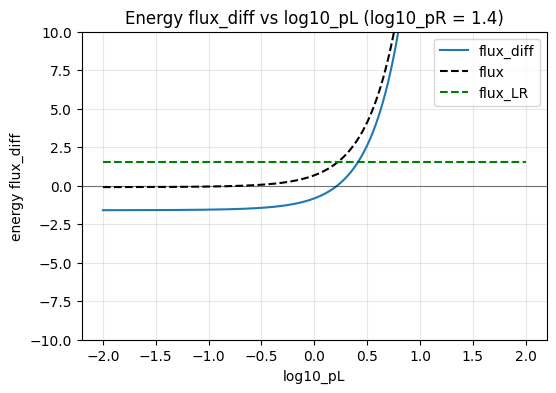

In [ ]:
# Energy flux_diff with only log10_pL varying and log10_pR fixed at 1.4.
N_plot = 1000
log10_pL = jnp.linspace(TRAIN_BOUNDS[2][0], TRAIN_BOUNDS[2][1], N_plot)

# Defaults match the 2D grid defaults above.
t = jnp.full_like(log10_pL, 0.5)
log10_rhoL = jnp.zeros_like(log10_pL)
log10_rhoR = jnp.zeros_like(log10_pL)
log10_pR = jnp.full_like(log10_pL, 0.)
uRL = jnp.full_like(log10_pL, 1)

x = jnp.stack([t, log10_rhoL, log10_pL, log10_rhoR, log10_pR, uRL], axis=-1)
flux = jax.vmap(F_true)(x)

rhoL = 10.0 ** log10_rhoL
rhoR = 10.0 ** log10_rhoR
pL = 10.0 ** log10_pL
pR = 10.0 ** log10_pR
uL = jnp.zeros_like(uRL)
uR = uRL

flux_L = jax.vmap(flux_from_primitive_state)(rhoL, uL, pL)
flux_R = jax.vmap(flux_from_primitive_state)(rhoR, uR, pR)
flux_LR = 0.5 * (flux_L + flux_R)
flux_diff = flux - flux_LR

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(log10_pL, flux_diff[:, 2], label='flux_diff')
ax.plot(log10_pL, flux[:, 2], '--', c='k', label='flux')
ax.plot(log10_pL, flux_LR[:, 2], '--', c='g', label='flux_LR')
ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
ax.set_xlabel("log10_pL")
ax.set_ylabel("energy flux_diff")
ax.set_title("Energy flux_diff vs log10_pL (log10_pR = 1.4)")
ax.legend()
ax.set_ylim(-10, 10)
ax.grid(True, alpha=0.3)
plt.show()

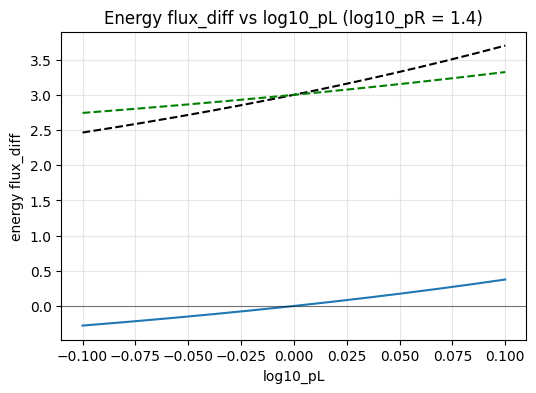

In [ ]:
# Energy flux_diff with only log10_pL varying and log10_pR fixed at 1.4.
N_plot = 1000
log10_pL = jnp.linspace(-0.1, 0.1, N_plot)

# Defaults match the 2D grid defaults above.
t = jnp.full_like(log10_pL, 0.5)
log10_rhoL = jnp.zeros_like(log10_pL)
log10_rhoR = jnp.zeros_like(log10_pL)
log10_pR = jnp.full_like(log10_pL, 0.)
uRL = jnp.zeros_like(log10_pL)

uL = jnp.full_like(uRL, 1.0)
from physics import compute_flux

x = jnp.stack([log10_rhoL, log10_pL, log10_rhoR, log10_pR, uRL], axis=-1)
gs = GasState.from_array(x)
flux = jax.vmap(lambda gs, uL: compute_flux(0.5, gs, uL))(gs, uL)

rhoL = 10.0 ** log10_rhoL
rhoR = 10.0 ** log10_rhoR
pL = 10.0 ** log10_pL
pR = 10.0 ** log10_pR
# uL = jnp.zeros_like(uRL)
uR = uRL + uL

flux_L = jax.vmap(flux_from_primitive_state)(rhoL, uL, pL)
flux_R = jax.vmap(flux_from_primitive_state)(rhoR, uR, pR)
flux_LR = 0.5 * (flux_L + flux_R)
flux_diff = flux - flux_LR

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(log10_pL, flux_diff[:, 2])
ax.plot(log10_pL, flux[:, 2], '--', c='k')
ax.plot(log10_pL, flux_LR[:, 2], '--', c='g')
ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
ax.set_xlabel("log10_pL")
ax.set_ylabel("energy flux_diff")
ax.set_title("Energy flux_diff vs log10_pL (log10_pR = 1.4)")
ax.grid(True, alpha=0.3)
plt.show()

min flux [ nan -inf  nan]
max flux [nan inf nan]


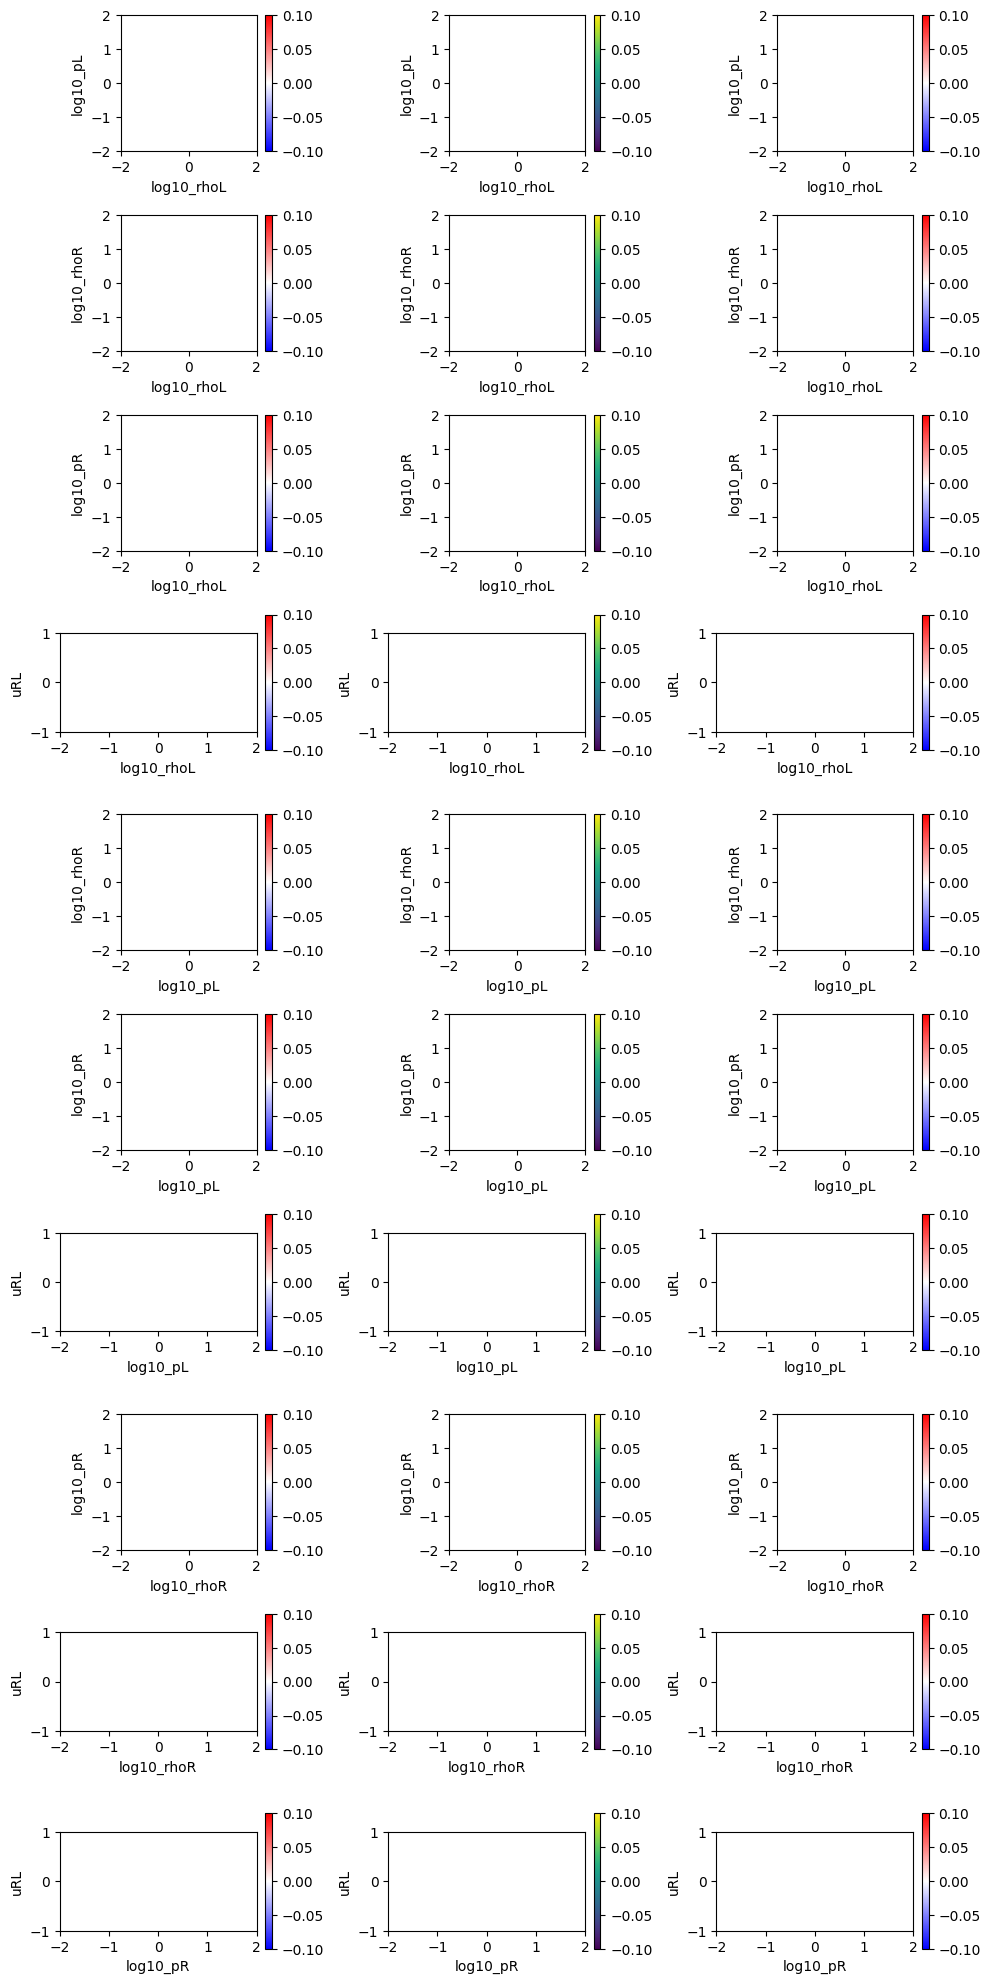

In [20]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):
    min_flux = jnp.minimum(min_flux, fluxes_div[i].min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, fluxes_div[i].max(axis=(0,1)))
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]

        if j==0:
            cmap = 'bwr'
            vmax = None
            vmin = None
        if j==1:
            cmap = 'viridis'
            vmax = None
            vmin = None
        if j==2:
            cmap = 'bwr'
            vmax = None
            vmin = None

        im = ax.imshow(fluxes_div[i][...,j].T, origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


In [6]:
gs = GasState(log10_rhoL=0, log10_pL=0, log10_rhoR=2, log10_pR=2, uRL=0)
x = jnp.concatenate([jnp.array([0.1]), gs.as_array()])
print(F_true(x))

[-40.84787123  63.28125    -76.58975856]


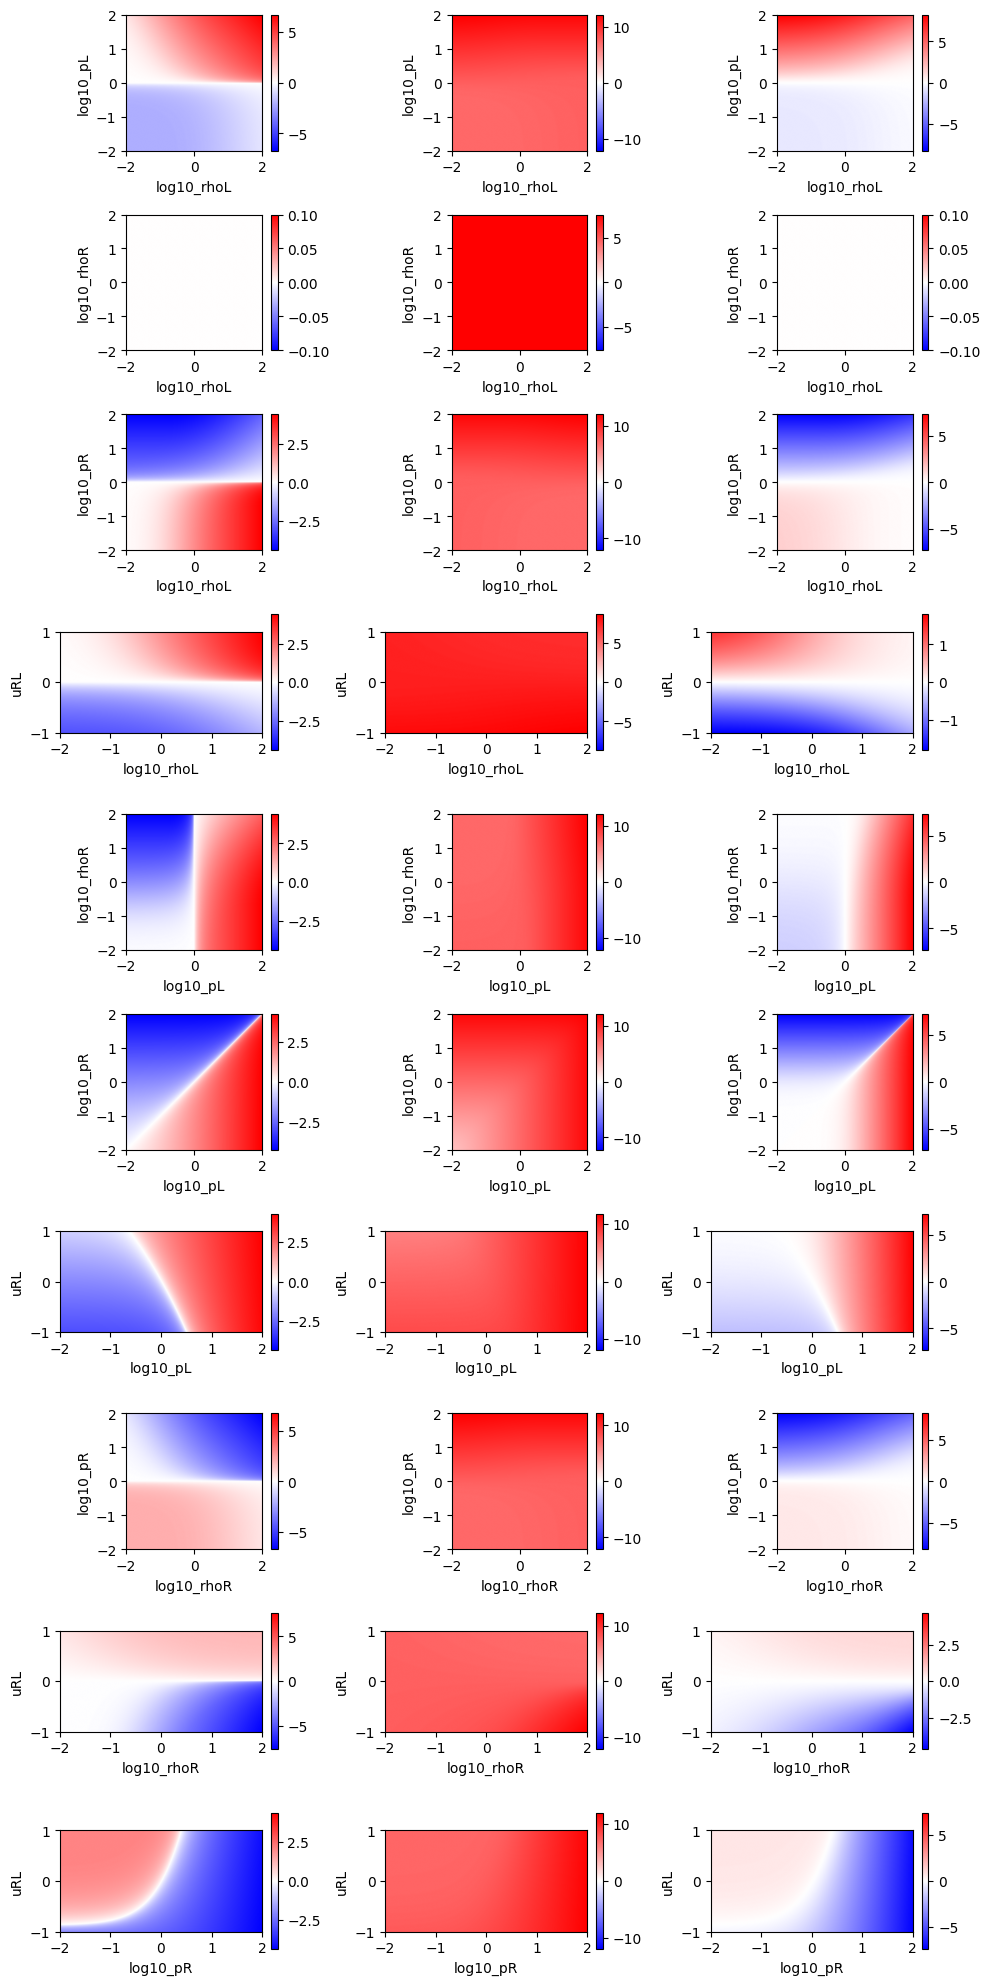

In [7]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE
MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / MY_FLUX_SCALE[j])
        vmax = jnp.abs(flux_scaled).max()
        im = ax.imshow(
            flux_scaled.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


In [51]:
print(FLUX_SCALE)

[1.e-05 1.e-03 1.e-05]


[[-3.52979272e-01  6.52965061e-01 -6.99518329e-01]
 [-3.52951617e-01  6.52979818e-01 -6.99480829e-01]
 [-3.52923704e-01  6.52994716e-01 -6.99442975e-01]
 ...
 [ 3.49684856e+00  6.41064399e+01  6.80362394e+02]
 [ 3.51328332e+00  6.46987298e+01  6.89874052e+02]
 [ 3.52979272e+00  6.52965061e+01  6.99518329e+02]]


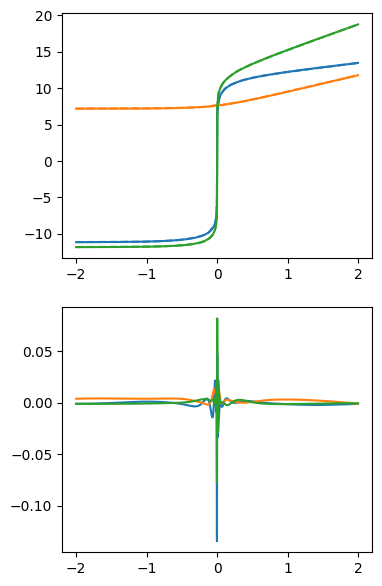

In [35]:
N = 1000
gs = GasState(log10_rhoL=jnp.zeros(N), 
              log10_pL=jnp.linspace(-2, 2, N), 
              log10_rhoR=jnp.zeros(N), 
              log10_pR=jnp.zeros(N), 
              uRL=jnp.zeros(N))

# Correct shape construction: stack each data point as a row
x = jnp.concatenate(
    [jnp.full((N, 1), 0.1), gs.as_array().reshape(N, -1)],
    axis=1
)

flux = jax.vmap(F_true)(x)
flux_pred = F_net(x)

# MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])
flux_scaled = jnp.arcsinh(flux / FLUX_SCALE)


print(flux)

fig, axs = plt.subplots(2, 1, figsize=(4, 7))

l = axs[0].plot(gs.log10_pL, flux_scaled[..., 0])
axs[0].plot(gs.log10_pL, flux_pred[..., 0], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 1])
axs[0].plot(gs.log10_pL, flux_pred[..., 1], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 2])
axs[0].plot(gs.log10_pL, flux_pred[..., 2], '--', color=l[0].get_color())


ax = axs[1]
err = (flux_pred - flux_scaled) / (flux_scaled + 1e-4)
ax.plot(gs.log10_pL, err[..., 0])
ax.plot(gs.log10_pL, err[..., 1])
ax.plot(gs.log10_pL, err[..., 2])
# ax.set_ylim(-10, 10)

plt.show()


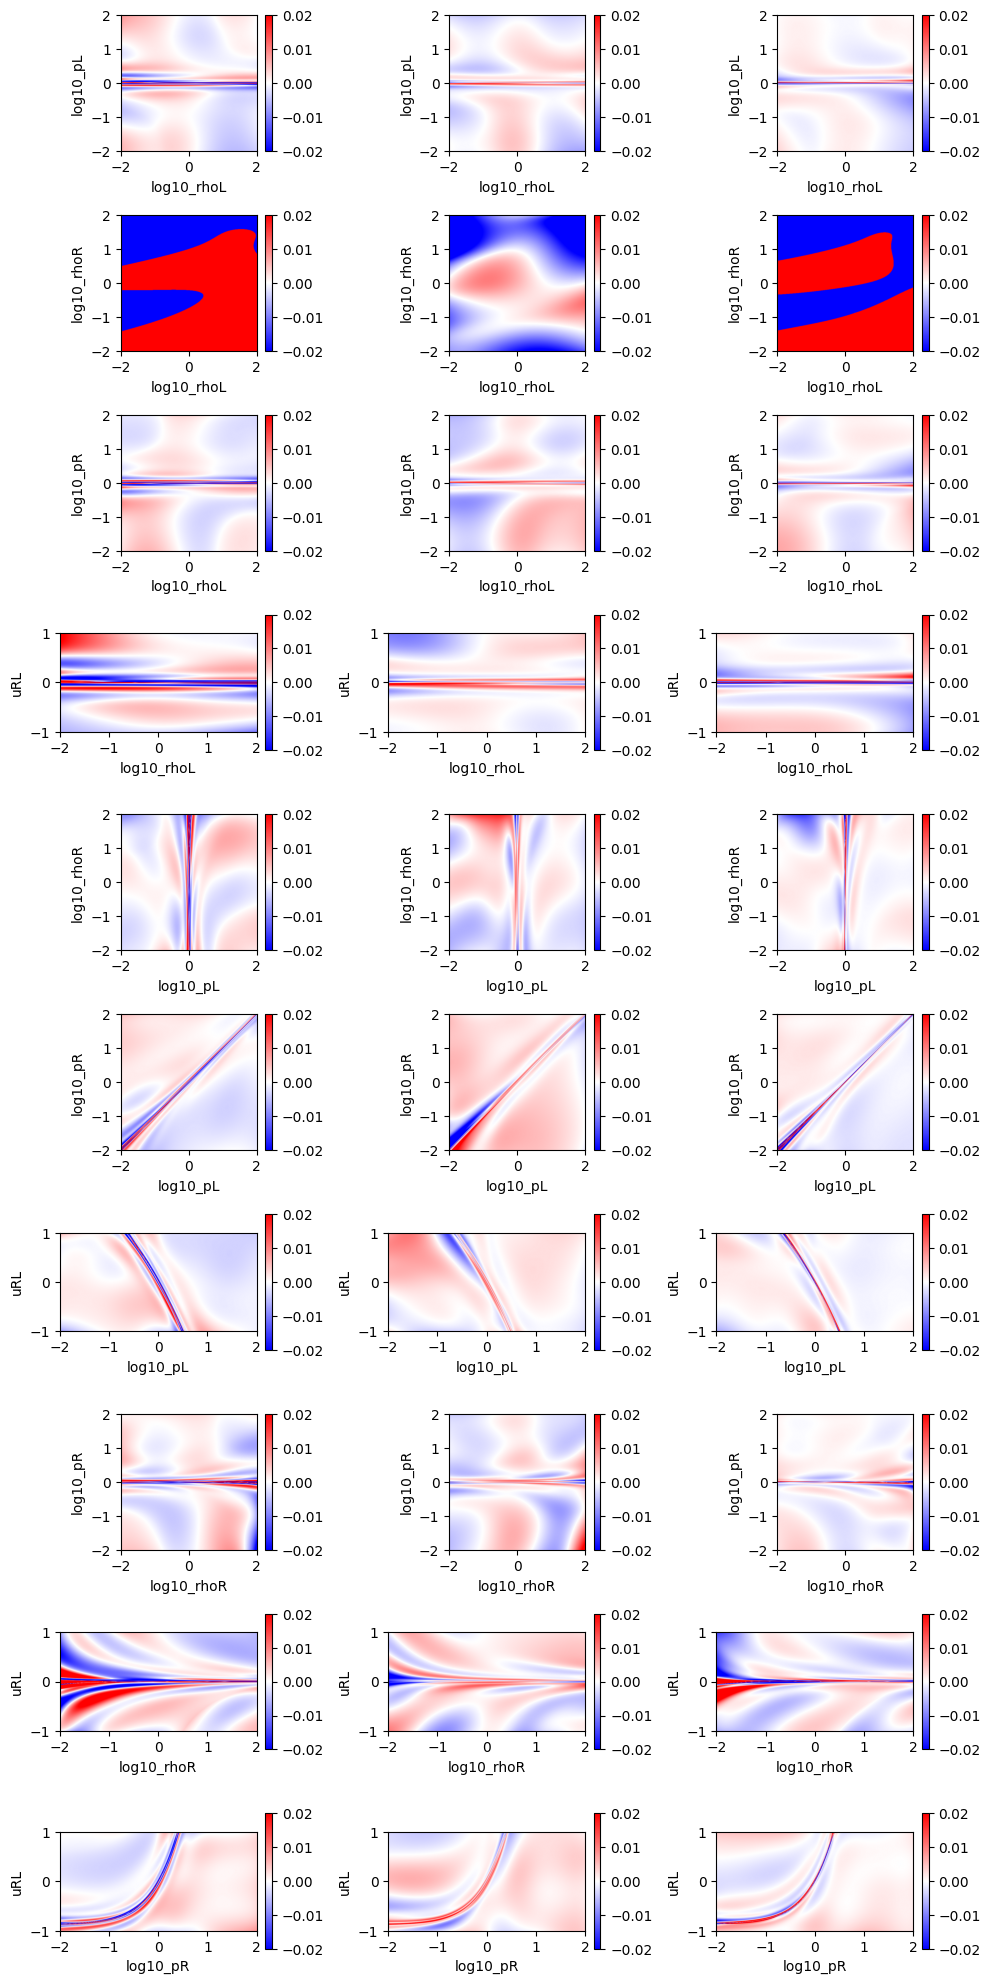

In [19]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / FLUX_SCALE[j])
        flux_scaled_pred = jnp.arcsinh(fluxes_pred[i][...,j] / FLUX_SCALE[j])
        err = (flux_scaled_pred - flux_scaled) / (jnp.abs(flux_scaled) + 1e-4)

        # vmax = jnp.bs(err).max()
        vmax = 0.02
        im = ax.imshow(
            err.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


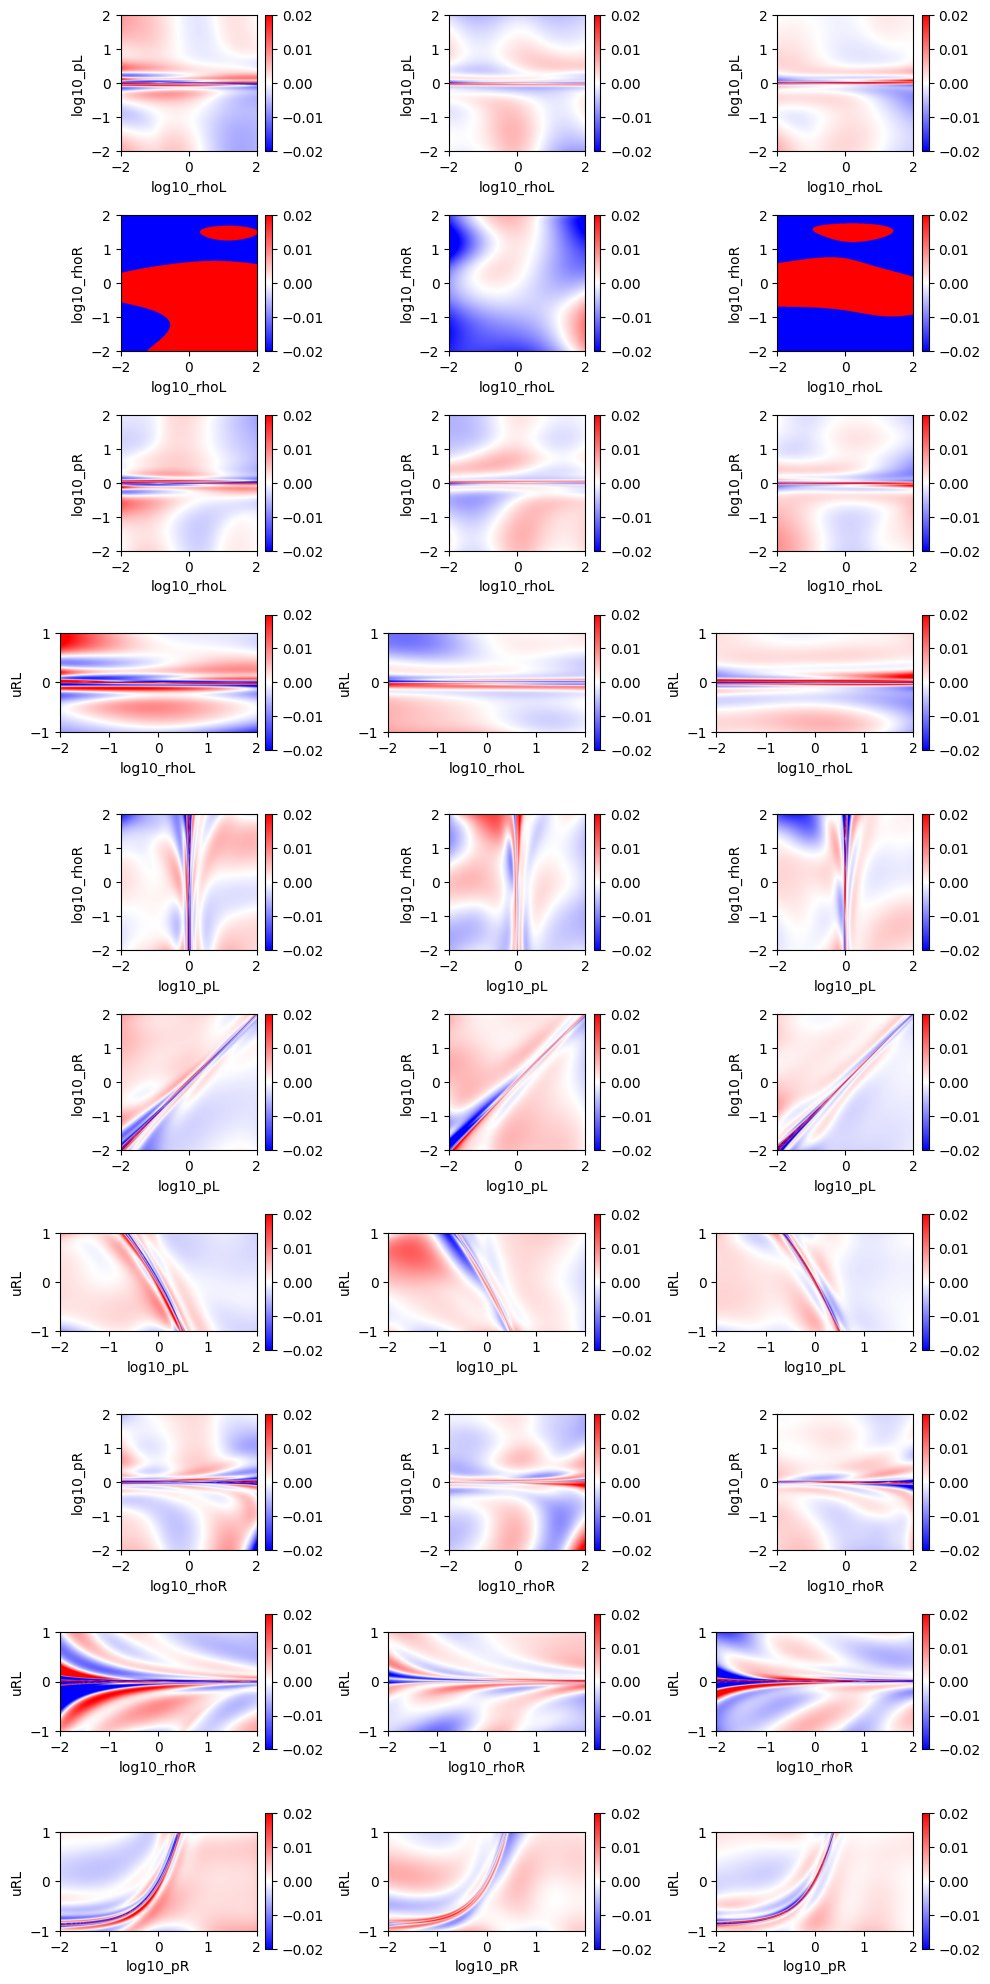

In [20]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / FLUX_SCALE[j])
        flux_scaled_pred = jnp.arcsinh(fluxes_rel_pred[i][...,j] / FLUX_SCALE[j])
        err = (flux_scaled_pred - flux_scaled) / (jnp.abs(flux_scaled) + 1e-4)

        # vmax = jnp.abs(err).max()
        vmax = 0.02
        im = ax.imshow(
            err.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()
